In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ================================================================
# CELL 2: IMPORTS
# ================================================================
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split


print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ================================================================
# CELL 3: PATHS AND SETTINGS
# ================================================================
DRIVE_ROOT = Path('/content/drive/MyDrive/PRJ3_DATA')
DATA_ROOT = DRIVE_ROOT / 'Assam_Model_Ready'
MODEL_DIR = DRIVE_ROOT / 'Assam_Models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2019, 2020, 2021, 2022, 2023]
PATCH_SIZE = 128

BATCH_SIZE = 8
EPOCHS = 20
LEARNING_RATE = 1e-4

In [ ]:
# ================================================================
# DEBUG: CHECK WHAT FILES ACTUALLY EXIST
# ================================================================
for year in YEARS:
    patch_dir = DATA_ROOT / str(year) / 'patches'

    print(f"\n{year} → {patch_dir}")

    if not patch_dir.exists():
        print("❌ patches folder missing")
        continue

    files = list(patch_dir.glob('*'))

    if not files:
        print("❌ no files inside")
        continue

    for f in files[:10]:
        print(" ", f.name)


2019 → /content/drive/MyDrive/PRJ3_DATA/Assam_Model_Ready/2019/patches
  X_pre_0.npy
  X_flood_0.npy
  X_dem_0.npy
  y_mask_0.npy
  X_pre_1.npy
  X_flood_1.npy
  X_dem_1.npy
  y_mask_1.npy

2020 → /content/drive/MyDrive/PRJ3_DATA/Assam_Model_Ready/2020/patches
  X_pre_0.npy
  X_flood_0.npy
  X_dem_0.npy
  y_mask_0.npy
  X_pre_1.npy
  X_flood_1.npy
  X_dem_1.npy
  y_mask_1.npy

2021 → /content/drive/MyDrive/PRJ3_DATA/Assam_Model_Ready/2021/patches
  X_pre_0.npy
  X_flood_0.npy
  X_dem_0.npy
  y_mask_0.npy
  X_pre_1.npy
  X_flood_1.npy
  X_dem_1.npy
  y_mask_1.npy

2022 → /content/drive/MyDrive/PRJ3_DATA/Assam_Model_Ready/2022/patches
  X_pre_0.npy
  X_flood_0.npy
  X_dem_0.npy
  y_mask_0.npy
  X_pre_1.npy
  X_flood_1.npy
  X_dem_1.npy
  y_mask_1.npy

2023 → /content/drive/MyDrive/PRJ3_DATA/Assam_Model_Ready/2023/patches
  X_pre_0.npy
  X_flood_0.npy
  X_dem_0.npy
  y_mask_0.npy
  X_pre_1.npy
  X_flood_1.npy
  X_dem_1.npy
  y_mask_1.npy


In [ ]:
# ================================================================
# CELL 4: LOAD PATCH DATA (CHUNK MODE + DEM)
# ================================================================
def load_year_patch_paths(year):
    patch_dir = DATA_ROOT / str(year) / 'patches'

    x_pre_files   = sorted(patch_dir.glob('X_pre_*.npy'))
    x_flood_files = sorted(patch_dir.glob('X_flood_*.npy'))
    x_dem_files   = sorted(patch_dir.glob('X_dem_*.npy'))
    y_files       = sorted(patch_dir.glob('y_mask_*.npy'))

    if not x_pre_files:
        print(f"Skipping {year}: no patch chunks found")
        return None

    if not (len(x_pre_files) == len(x_flood_files) == len(x_dem_files) == len(y_files)):
        print(f"{year}: mismatch in chunk files")
        return None

    # Count total patches
    total = 0
    for f in x_pre_files:
        arr = np.load(f, mmap_mode='r')
        total += arr.shape[0]

    print(year,
          "| chunks:", len(x_pre_files),
          "| total patches:", total)

    return {
        'year': year,
        'x_pre_paths': x_pre_files,
        'x_flood_paths': x_flood_files,
        'x_dem_paths': x_dem_files,
        'y_paths': y_files,
        'count': total,
        'channels': np.load(x_pre_files[0], mmap_mode='r').shape[1],
        'dem_channels': np.load(x_dem_files[0], mmap_mode='r').shape[1],
    }


# ================================================================
# LOAD ALL YEARS
# ================================================================
year_infos = []

for year in YEARS:
    info = load_year_patch_paths(year)
    if info is not None:
        year_infos.append(info)

if not year_infos:
    raise FileNotFoundError("No patch data found!")

# ================================================================
# SUMMARY
# ================================================================
sample_channels = year_infos[0]['channels']
sample_dem_channels = year_infos[0]['dem_channels']
total_patches = sum(info['count'] for info in year_infos)

print("\nCombined:")
print("Total patches:", total_patches)
print("S1 channels :", sample_channels)
print("DEM channels:", sample_dem_channels)

2019 | chunks: 2 | total patches: 2206
2020 | chunks: 2 | total patches: 2111
2021 | chunks: 2 | total patches: 2166
2022 | chunks: 2 | total patches: 2239
2023 | chunks: 2 | total patches: 2237

Combined:
Total patches: 10959
S1 channels : 4
DEM channels: 1


In [ ]:
# ================================================================
# CELL 5: BUILD GLOBAL INDEX (CHUNK VERSION)
# ================================================================
global_items = []

for year_i, info in enumerate(year_infos):

    for chunk_i, path in enumerate(info['y_paths']):
        arr = np.load(path, mmap_mode='r')

        for local_i in range(arr.shape[0]):
            global_items.append((year_i, chunk_i, local_i))

global_items = np.array(global_items, dtype=np.int32)

print('Global index:', global_items.shape)

Global index: (10959, 3)


In [ ]:
def estimate_positive_fraction(year_infos, max_samples_per_year=50):
    values = []

    for info in year_infos:

        all_samples = []

        for path in info['y_paths']:
            y = np.load(path, mmap_mode='r')

            sample_count = min(len(y), max_samples_per_year)
            idx = np.linspace(0, len(y) - 1, sample_count).astype(int)

            all_samples.append(y[idx])

        if all_samples:
            combined = np.concatenate(all_samples, axis=0)
            values.append(float(combined.mean()))

    return float(np.mean(values)) if values else 0.0


print('Estimated mask positive fraction:',
      estimate_positive_fraction(year_infos))

Estimated mask positive fraction: 0.14044360351562502


In [ ]:
# ================================================================
# CELL 6: TRAIN / VALIDATION SPLIT
# ================================================================
train_idx, val_idx = train_test_split(
    np.arange(len(global_items)),
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

print('Train patches:', len(train_idx))
print('Val patches:', len(val_idx))

Train patches: 8767
Val patches: 2192


In [ ]:
# ================================================================
# CELL 7: MEMORY-LIGHT KERAS SEQUENCE (CHUNK + DEM)
# ================================================================
class SiamesePatchSequence(tf.keras.utils.Sequence):
    def __init__(self, year_infos, global_items, selected_indices, batch_size, shuffle=True):
        super().__init__()
        self.year_infos = year_infos
        self.global_items = global_items
        self.selected_indices = np.array(selected_indices, dtype=np.int32)
        self.batch_size = batch_size
        self.shuffle = shuffle

        # 🔥 Load chunked arrays
        self.arrays = []
        for info in year_infos:
            year_data = []

            for i in range(len(info['x_pre_paths'])):
                year_data.append({
                    'x_pre':   np.load(info['x_pre_paths'][i], mmap_mode='r'),
                    'x_flood': np.load(info['x_flood_paths'][i], mmap_mode='r'),
                    'x_dem':   np.load(info['x_dem_paths'][i], mmap_mode='r'),
                    'y':       np.load(info['y_paths'][i], mmap_mode='r'),
                })

            self.arrays.append(year_data)

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.selected_indices) / self.batch_size))

    def __getitem__(self, batch_idx):
        batch_indices = self.selected_indices[
            batch_idx * self.batch_size:(batch_idx + 1) * self.batch_size
        ]

        x_pre_batch, x_flood_batch, x_dem_batch, y_batch = [], [], [], []

        for global_idx in batch_indices:
            year_i, chunk_i, local_i = self.global_items[global_idx]

            arrays = self.arrays[int(year_i)][int(chunk_i)]

            # C,H,W → H,W,C
            x_pre   = np.transpose(arrays['x_pre'][int(local_i)], (1, 2, 0))
            x_flood = np.transpose(arrays['x_flood'][int(local_i)], (1, 2, 0))
            x_dem   = np.transpose(arrays['x_dem'][int(local_i)], (1, 2, 0))
            y       = np.transpose(arrays['y'][int(local_i)], (1, 2, 0))

            x_pre_batch.append(x_pre)
            x_flood_batch.append(x_flood)
            x_dem_batch.append(x_dem)
            y_batch.append(y)

        return (
            {
                'pre_image':  np.stack(x_pre_batch).astype(np.float32),
                'flood_image': np.stack(x_flood_batch).astype(np.float32),
                'dem_image':   np.stack(x_dem_batch).astype(np.float32),
            },
            np.stack(y_batch).astype(np.float32),
        )

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.selected_indices)


# ================================================================
# CREATE DATASETS
# ================================================================
train_ds = SiamesePatchSequence(year_infos, global_items, train_idx, BATCH_SIZE, shuffle=True)
val_ds   = SiamesePatchSequence(year_infos, global_items, val_idx, BATCH_SIZE, shuffle=False)

print('Train batches:', len(train_ds))
print('Val batches:', len(val_ds))

Train batches: 1096
Val batches: 274


In [ ]:
# ================================================================
# CELL 8: MODEL BUILDING BLOCKS (FINAL - WITH DEM)
# ================================================================
import tensorflow as tf

# ------------------------
# BASIC CONV BLOCK
# ------------------------
def conv_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x


# ------------------------
# ENCODER (USED FOR S1 + DEM)
# ------------------------
def encoder_branch(input_tensor, base_filters=24):
    c1 = conv_block(input_tensor, base_filters)
    p1 = tf.keras.layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, base_filters * 2)
    p2 = tf.keras.layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, base_filters * 4)
    p3 = tf.keras.layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, base_filters * 8)
    p4 = tf.keras.layers.MaxPooling2D()(c4)

    b = conv_block(p4, base_filters * 16)

    return b, [c1, c2, c3, c4]


# ------------------------
# DECODER BLOCK
# ------------------------
def decoder_block(x, skip, filters):
    x = tf.keras.layers.UpSampling2D()(x)
    x = tf.keras.layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x


# ------------------------
# SIAMESE U-NET + DEM
# ------------------------
def build_siamese_unet(
    input_shape=(128, 128, 4),
    dem_shape=(128, 128, 1),
    base_filters=24
):

    # ===== INPUTS =====
    pre_input   = tf.keras.Input(shape=input_shape, name='pre_image')
    flood_input = tf.keras.Input(shape=input_shape, name='flood_image')
    dem_input   = tf.keras.Input(shape=dem_shape, name='dem_image')

    # ===== SHARED ENCODER (S1) =====
    encoder_input = tf.keras.Input(shape=input_shape)
    encoder_output = encoder_branch(encoder_input, base_filters)
    shared_encoder = tf.keras.Model(encoder_input, encoder_output, name='shared_encoder')

    pre_b, pre_skips = shared_encoder(pre_input)
    flood_b, flood_skips = shared_encoder(flood_input)

    # ===== DEM ENCODER (SEPARATE WEIGHTS) =====
    dem_b, dem_skips = encoder_branch(dem_input, base_filters)

    # ===== BOTTLENECK FUSION =====
    b = tf.keras.layers.Concatenate()([
        pre_b,
        flood_b,
        tf.keras.layers.Subtract()([flood_b, pre_b]),  # change info
        dem_b
    ])

    # ===== SKIP FUSION =====
    s4 = tf.keras.layers.Concatenate()([
        pre_skips[3],
        flood_skips[3],
        tf.keras.layers.Subtract()([flood_skips[3], pre_skips[3]]),
        dem_skips[3],
    ])

    s3 = tf.keras.layers.Concatenate()([
        pre_skips[2],
        flood_skips[2],
        tf.keras.layers.Subtract()([flood_skips[2], pre_skips[2]]),
        dem_skips[2],
    ])

    s2 = tf.keras.layers.Concatenate()([
        pre_skips[1],
        flood_skips[1],
        tf.keras.layers.Subtract()([flood_skips[1], pre_skips[1]]),
        dem_skips[1],
    ])

    s1 = tf.keras.layers.Concatenate()([
        pre_skips[0],
        flood_skips[0],
        tf.keras.layers.Subtract()([flood_skips[0], pre_skips[0]]),
        dem_skips[0],
    ])

    # ===== DECODER =====
    d4 = decoder_block(b, s4, base_filters * 8)
    d3 = decoder_block(d4, s3, base_filters * 4)
    d2 = decoder_block(d3, s2, base_filters * 2)
    d1 = decoder_block(d2, s1, base_filters)

    # ===== OUTPUT =====
    output = tf.keras.layers.Conv2D(1, 1, activation='sigmoid', name='flood_mask')(d1)

    # ===== MODEL =====
    model = tf.keras.Model(
        inputs=[pre_input, flood_input, dem_input],
        outputs=output,
        name='assam_siamese_unet_dem'
    )

    return model

In [ ]:
# ================================================================
# CELL 9: LOSSES AND METRICS
# ================================================================
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)


def iou_metric(y_true, y_pred, threshold=0.5, smooth=1e-6):
    y_pred_bin = tf.cast(y_pred > threshold, tf.float32)
    y_true = tf.cast(y_true, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred_bin)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_bin) - intersection
    return (intersection + smooth) / (union + smooth)

In [ ]:
# ================================================================
# CELL 10: BUILD AND TRAIN (WITH DEM)
# ================================================================
model = build_siamese_unet(
    input_shape=(PATCH_SIZE, PATCH_SIZE, sample_channels),        # S1 channels (4)
    dem_shape=(PATCH_SIZE, PATCH_SIZE, sample_dem_channels),      # DEM channel (1)
    base_filters=24,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        iou_metric,
        tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
    ],
)

model.summary()


callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DIR / 'assam_siamese_unet_dem_best.keras'),  # renamed
        monitor='val_dice_coef',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef',
        mode='max',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Model: "assam_siamese_unet_dem"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dem_image           │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 128, 128,  │        216 │ dem_image[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         96 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 128, 128,  │      5,184 │ activation_38[0]… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         96 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_39       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 64, 64,    │          0 │ activation_39[0]… │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 64, 64,    │     10,368 │ max_pooling2d_12… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        192 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_40       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 64, 64,    │     20,736 │ activation_40[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        192 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_41       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 32, 32,    │          0 │ activation_41[0]… │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 32, 32,    │     41,472 │ max_pooling2d_13… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        384 │ conv2d_42[0][0] 

 Total params: 10,389,073 (39.63 MB)

 Trainable params: 10,381,681 (39.60 MB)

 Non-trainable params: 7,392 (28.88 KB)

Epoch 1/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - binary_accuracy: 0.9024 - dice_coef: 0.5335 - iou_metric: 0.5369 - loss: 0.7320
Epoch 1: val_dice_coef improved from None to 0.72437, saving model to /content/drive/MyDrive/PRJ3_DATA/Assam_Models/assam_siamese_unet_dem_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PRJ3_DATA/Assam_Models/assam_siamese_unet_dem_best.keras
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 261s 194ms/step - binary_accuracy: 0.9279 - dice_coef: 0.6177 - iou_metric: 0.6166 - loss: 0.5819 - val_binary_accuracy: 0.9556 - val_dice_coef: 0.7244 - val_iou_metric: 0.7253 - val_loss: 0.3989 - learning_rate: 1.0000e-04
Epoch 2/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - binary_accuracy: 0.9482 - dice_coef: 0.7299 - iou_metric: 0.6936 - loss: 0.4064
Epoch 2: val_dice_coef improved from 0.72437 to 0.76736, saving model to /content/drive/MyDrive/PRJ3_DATA/Assam_Models/assam_siamese_unet_dem_best.keras

Epoch 2: finished saving model to /content/drive/My

In [ ]:
# ================================================================
# CELL 11: SAVE FINAL MODEL
# ================================================================
final_model_path = MODEL_DIR / 'assam_siamese_unet_final.keras'
model.save(final_model_path)
print('Saved:', final_model_path)

Saved: /content/drive/MyDrive/PRJ3_DATA/Assam_Models/assam_siamese_unet_final.keras


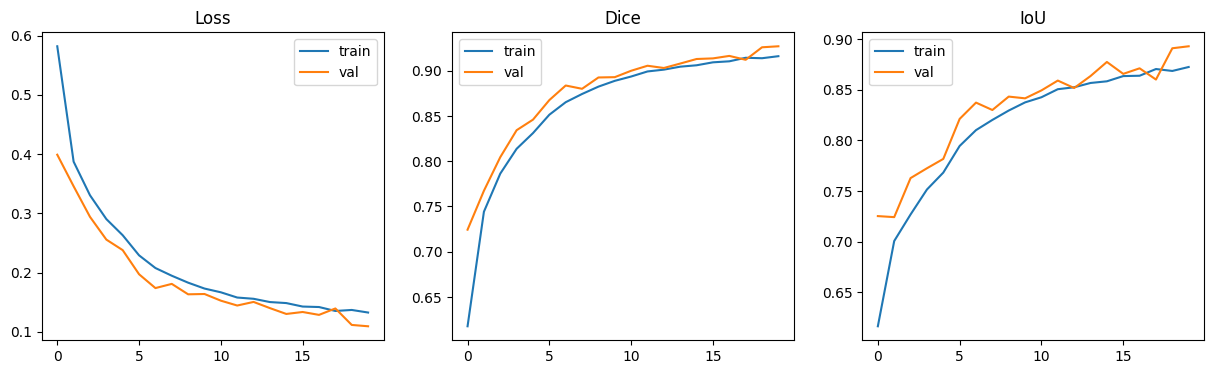

In [ ]:
# ================================================================
# CELL 12: PLOT TRAINING CURVES
# ================================================================
def plot_history(history):
    hist = history.history

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(hist['loss'], label='train')
    plt.plot(hist['val_loss'], label='val')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(hist['dice_coef'], label='train')
    plt.plot(hist['val_dice_coef'], label='val')
    plt.title('Dice')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(hist['iou_metric'], label='train')
    plt.plot(hist['val_iou_metric'], label='val')
    plt.title('IoU')
    plt.legend()

    plt.show()


plot_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


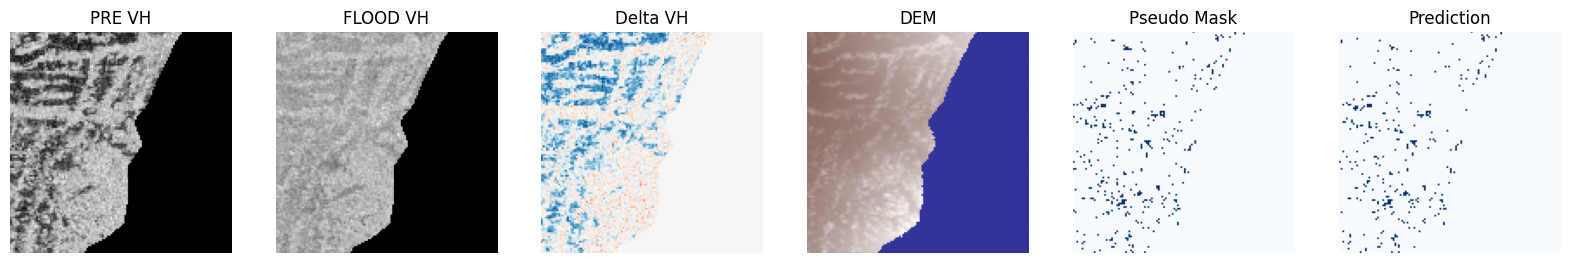

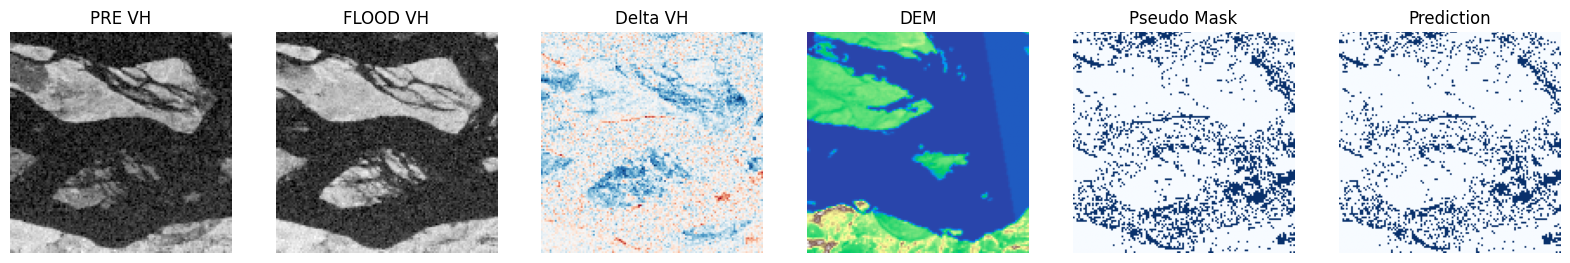

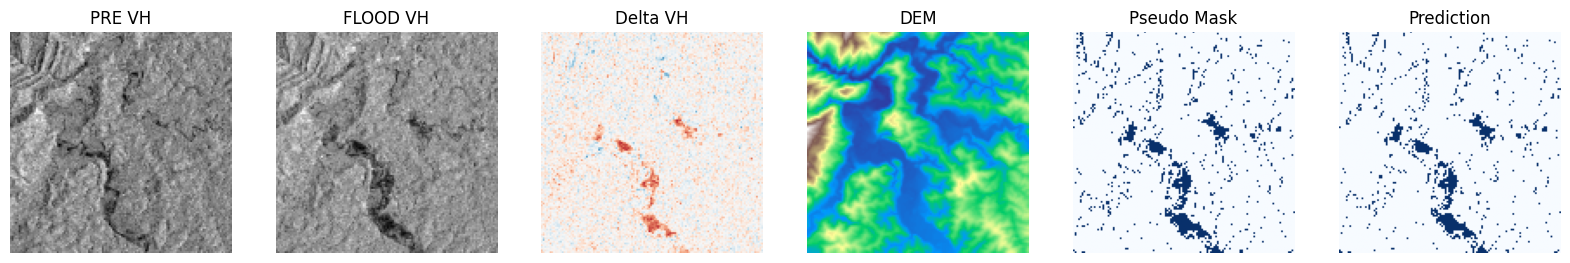

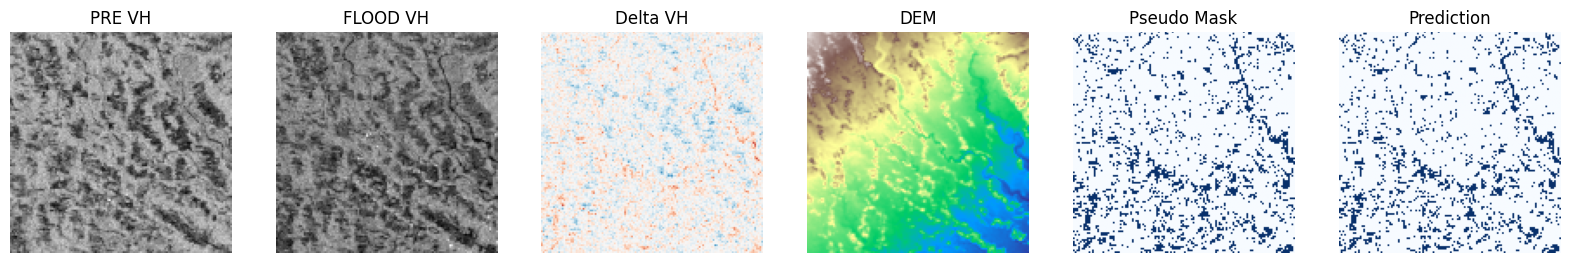

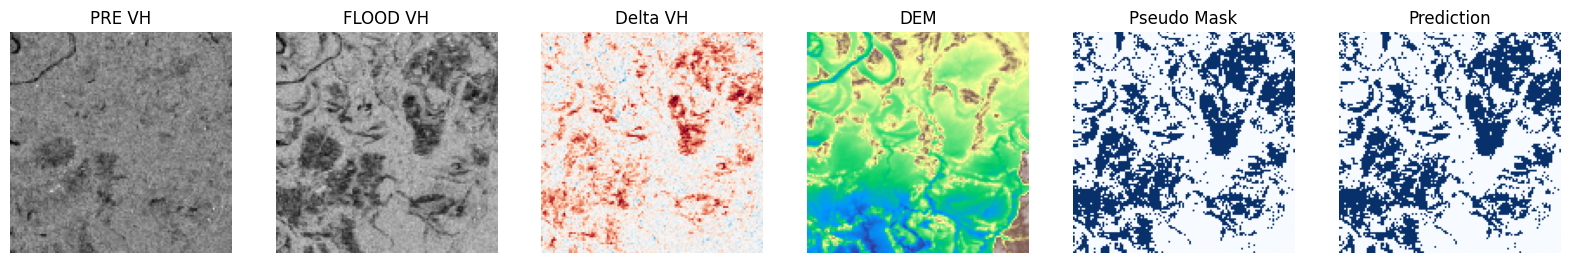

In [ ]:
# ================================================================
# CELL 13: VISUALIZE PREDICTIONS (WITH DEM)
# ================================================================
def visualize_predictions(model, x_pre, x_flood, x_dem, y_true, count=5, threshold=0.5):
    count = min(count, len(y_true))

    preds = model.predict([
        x_pre[:count],
        x_flood[:count],
        x_dem[:count]   # ✅ DEM added
    ])

    for i in range(count):
        pre_vh = x_pre[i, :, :, 1]
        flood_vh = x_flood[i, :, :, 1]
        delta_vh = flood_vh - pre_vh

        pred = preds[i, :, :, 0]
        pred_bin = pred > threshold
        truth = y_true[i, :, :, 0]

        plt.figure(figsize=(20, 4))

        plt.subplot(1, 6, 1)
        plt.imshow(pre_vh, cmap='gray')
        plt.title('PRE VH')
        plt.axis('off')

        plt.subplot(1, 6, 2)
        plt.imshow(flood_vh, cmap='gray')
        plt.title('FLOOD VH')
        plt.axis('off')

        plt.subplot(1, 6, 3)
        plt.imshow(delta_vh, cmap='RdBu', vmin=-0.4, vmax=0.4)
        plt.title('Delta VH')
        plt.axis('off')

        plt.subplot(1, 6, 4)
        plt.imshow(x_dem[i, :, :, 0], cmap='terrain')   # ✅ DEM visualization
        plt.title('DEM')
        plt.axis('off')

        plt.subplot(1, 6, 5)
        plt.imshow(truth, cmap='Blues')
        plt.title('Pseudo Mask')
        plt.axis('off')

        plt.subplot(1, 6, 6)
        plt.imshow(pred_bin, cmap='Blues')
        plt.title('Prediction')
        plt.axis('off')

        plt.show()


# ========================
# GET BATCH FROM VALIDATION
# ========================
val_preview, val_preview_y = val_ds[0]

visualize_predictions(
    model,
    val_preview['pre_image'],
    val_preview['flood_image'],
    val_preview['dem_image'],   # ✅ NEW
    val_preview_y,
    count=5,
)

In [ ]:
# ================================================================
# CELL 14: SAVE VALIDATION PREDICTIONS
# ================================================================
pred_dir = DRIVE_ROOT / 'Assam_Model_Predictions'
pred_dir.mkdir(parents=True, exist_ok=True)

val_preds = model.predict(val_ds)
np.save(pred_dir / 'val_predictions.npy', val_preds.astype(np.float32))

# Save only the first validation batch truth to avoid creating a large RAM copy.
np.save(pred_dir / 'val_truth_preview.npy', val_preview_y.astype(np.float32))

print('Predictions saved to:', pred_dir)

274/274 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step
Predictions saved to: /content/drive/MyDrive/PRJ3_DATA/Assam_Model_Predictions


In [ ]:
best_model = model

results = best_model.evaluate(val_ds, verbose=1)
print(dict(zip(best_model.metrics_names, results)))

274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - binary_accuracy: 0.9844 - dice_coef: 0.9269 - iou_metric: 0.8928 - loss: 0.1094
{'loss': 0.1094232052564621, 'compile_metrics': 0.9269494414329529}


In [ ]:
plt.savefig('/content/drive/MyDrive/PRJ3_DATA/Assam_Model_Predictions/siamese_unet_prediction_examples.png',
            dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [ ]:
model.save('/content/drive/MyDrive/PRJ3_DATA/Assam_Models/assam_siamese_unet_final.keras')

In [ ]:
with open('/content/drive/MyDrive/PRJ3_DATA/Assam_Models/siamese_unet_metrics.txt', 'w') as f:
    f.write('Validation results on SAR-derived pseudo flood masks\n')
    f.write('Binary accuracy: 0.9844\n')
    f.write('Dice coefficient: 0.9269\n')
    f.write('IoU: 0.8928\n')
    f.write('Loss: 0.1094\n')